# Assignment 3

Supervised Learning - model training and evaluation

Aesha Gandhi 
2026-02-04















<div style="page-break-before: always;"></div>


In [11]:
!pip install -q seaborn
# !pip install -q torch torchvision
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.4.2
!pip install black nb_black
!pip install nbconvert
!pip install jupyter-black black


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Found existing installation: scikit-learn 1.4.2
Uninstalling scikit-learn-1.4.2:
  Successfully uninstalled scikit-learn-1.4.2
  Using cached scikit_learn-1.4.2-cp312-cp312-macosx_10_9_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.4.2-cp312-cp312-macosx_10_9_x86_64.whl (11.6 MB)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
  Using cached nb_black-1.0.7.tar.gz (4.8 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [3 lines of output]
      error in nb_black setup command: 'install_requires' must be a string or iterable of strings containing valid project/version requirement specifiers; Expected semicolon (after name with no version s

<div style="page-break-before: always;"></div>


<style>
pre {
    white-space: pre-wrap;
    word-wrap: break-word;
}
</style>


In [12]:
import jupyter_black

jupyter_black.load()
jupyter_black.load(line_length=79)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns


from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, roc_auc_score, f1_score
import warnings

warnings.filterwarnings("ignore")

<div style="page-break-before: always;"></div>


## Exercise 1 - Classification using logistic regression: build it from the ground up


### A. Load, prepare, and plot your data


### 1.1 ###

In [14]:
data = pd.read_csv("A3_Q1_data.csv")
train, test = train_test_split(data, test_size=0.3, random_state=42)
# test = test.drop(columns=['y'])

train.head()

,x1,x2,y
169,-2.234917,-0.611168,1
97,1.171522,0.212631,0
31,-0.230629,-1.911302,1
12,0.172939,-0.116064,1
35,-0.889697,-1.462455,1


In [15]:
test.head()

,x1,x2,y
95,0.032457,-0.441788,0
15,0.241180,-0.597400,0
30,0.577972,-0.401149,1
158,-1.470858,-1.495579,1
128,-1.004990,0.994876,1


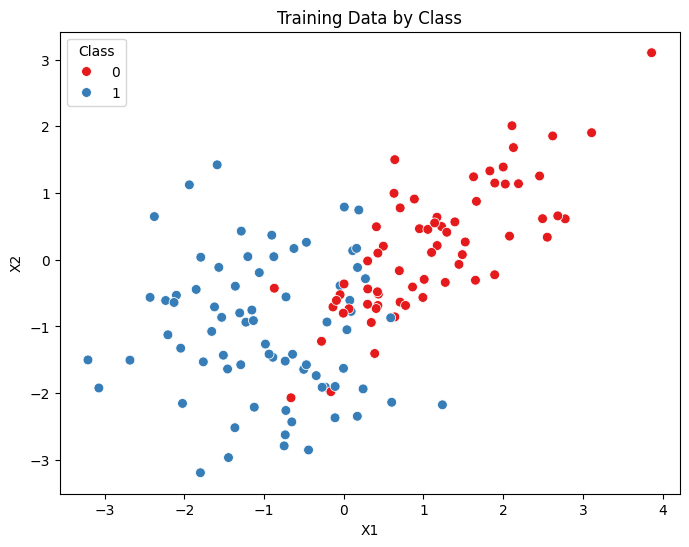

In [16]:
# plot training data by class, x1 on x axis, x2 on y axis, color by class
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=train,
    x="x1",
    y="x2",
    hue="y",
    size="y",
    palette="Set1",
    sizes=(50, 50),
    legend="full",
)
plt.title("Training Data by Class")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend(title="Class")
plt.show()

**The data does appear separable as the two classes appear to be in different clusters (colors blue and red above), in which class 1 is mostly on the left and class 0 is mostly on the right, with only some points overlapping. Logistic regression could be a good choice because the data looks linearly separable and the classes are binary 0,1.**

<div style="page-break-before: always;"></div>


### 1.2 ###

In [17]:
#  Do the data require any preprocessing due to missing values, scale differences (e.g. different ranges of values), etc.? If so, how did you handle these issues?

# clean for missing value and preprocessing steps
print("Checking for missing values:")
print(train.isnull().sum())

# scale differences
print("\nSummary statistics for training data:")
print(train.describe())
# The features x1 and x2 have different ranges, so we will standardize them to have mean 0 and standard deviation 1.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train[["x1", "x2"]] = scaler.fit_transform(train[["x1", "x2"]])
test[["x1", "x2"]] = scaler.transform(test[["x1", "x2"]])

Checking for missing values:
x1    0
x2    0
y     0
dtype: int64

Summary statistics for training data:
               x1          x2           y
count  140.000000  140.000000  140.000000
mean     0.013655   -0.476073    0.528571
std      1.395859    1.180769    0.500975
min     -3.210005   -3.193456    0.000000
25%     -1.002628   -1.408136    0.000000
50%      0.022974   -0.519640    1.000000
75%      0.960201    0.357610    1.000000
max      3.862195    3.103541    1.000000


**The data does not have any missing values for any of the features or class labels. The scatterplot shows both x1 and x2 in reasonable ranges of -3 and 3, but x2 has slightly less variance in its values, so scaling can be beneficial just in case, especially for logistic regression and if using regularization.**

<div style="page-break-before: always;"></div>


### B. Defining our hypothesis set: logistic regression models

Given that our data consists of two features, our logistic regression
problem will be applied to a two-dimensional feature space. Recall that
our logistic regression model is defined by the expression:

$$f(\mathbf{x}_i,\mathbf{w})=\sigma(\mathbf{w}^{\top} \mathbf{x}_i)$$

where the sigmoid function is defined as
$\sigma(x) = \dfrac{e^x}{1+e^{x}}= \dfrac{1}{1+e^{-x}}$. Also, since
this is a two-dimensional problem, we define
$\mathbf{w}^{\top} \mathbf{x}_i = w_0 x_{i,0} + w_1 x_{i,1} + w_2 x_{i,2}$
and here, $\mathbf{x}_i=[x_{i,0}, x_{i,1}, x_{i,2}]^{\top}$, and
$x_{i,0} \triangleq 1$

Remember from class that we impose an interpretation on our logistic
regression classifier output (the confidence score) to be the
conditional probability that the target variable for a given sample
$y_i$ is from class “1”, given the observed features, $\mathbf{x}_i$.
For one sample of training data, $(y_i, \mathbf{x}_i)$, this probability
can be written as:

$$P(Y=1|X=\mathbf{x}_i) = f(\mathbf{x}_i,\mathbf{w})=\sigma(\mathbf{w}^{\top} \mathbf{x}_i)$$

In the context of maximizing the likelihood of our parameters given the
data, we define this to be the likelihood function
$L(\mathbf{w}|y_i,\mathbf{x}_i)$, corresponding to one sample from the
training dataset.

*Aside: the careful reader will note that this use of the term
likelihood differs from the definition in Bayes’ Rule. In the context of
training a logistic regression model, the likelihood we are interested
in is this case answers the question: “if this model was true, how
plausible are the data I observed?” In this context, the likelihood
function is a function of our model **parameters**, $\mathbf{w}$. It’s
our goal to use this to choose the parameters to maximize the likelihood
function.*

<div style="page-break-before: always;"></div>


### C. Find the cost function to measure how well the model parameters, $\mathbf{w}$, fit the model to the training data.


#### 1.3 ####
![img](Hw3_1.3.jpeg)

<div style="page-break-before: always;"></div>


#### 1.4 ####
![img](Hw3_1.4.jpeg)

<div style="page-break-before: always;"></div>


#### 1.5 ####
![img](Hw3_1.5.jpeg)

<div style="page-break-before: always;"></div>


#### 1.6 ####
![img](Hw3_1.6.jpeg)

<div style="page-break-before: always;"></div>


## 

### D. Implement gradient descent and your logistic regression algorithm


In [18]:
# Logistic regression class
class Logistic_regression:
    # Class constructor
    def __init__(self):
        self.w = None  # logistic regression weights
        self.saved_w = []  # Since this is a small problem, we can save the weights
        #  at each iteration of gradient descent to build our
        #  learning curves
        # returns nothing
        pass

    # Method for calculating the sigmoid function of w^T X for an input set of weights
    def sigmoid(self, X, w):
        # returns the value of the sigmoid

        return 1 / (1 + np.exp(-X @ w))

    # Cost function for an input set of weights
    def cost(self, X, y, w):
        # returns the average cross entropy cost
        return -np.mean(
            y * np.log(self.sigmoid(X, w)) + (1 - y) * np.log(1 - self.sigmoid(X, w))
        )

    # Update the weights in an iteration of gradient descent
    def gradient_descent(self, X, y, lr):
        # returns a scalar of the magnitude of the Euclidean norm
        #  of the change in the weights during one gradient descent step
        updated = self.w - lr * (X.T @ (self.sigmoid(X, self.w) - y)) / X.shape[0]
        norm = np.linalg.norm(updated - self.w)
        self.w = updated
        return norm

    # Fit the logistic regression model to the data through gradient descent

    def fit(
        self,
        X,
        y,
        w_init=None,
        lr=0.1,
        delta_thresh=1e-6,
        max_iter=5000,
        verbose=False,
        X_test=None,
        y_test=None,
    ):

        # weight init: random in [0,1] if not provided
        if w_init is None:
            self.w = np.random.uniform(0, 1, X.shape[1])
            # np.random.rand(X.shape[1])
        else:
            self.w = w_init

        self.saved_w = [self.w.copy()]

        # store learning curves
        self.train_costs = [self.cost(X, y, self.w)]
        self.test_costs = []
        if X_test is not None and y_test is not None:
            self.test_costs = [self.cost(X_test, y_test, self.w)]

        # perform gradient descent and save weights and costs at each step
        for i in range(max_iter):
            delta = self.gradient_descent(X, y, lr)
            self.saved_w.append(self.w.copy())

            # compute costs at each step
            self.train_costs.append(self.cost(X, y, self.w))
            if X_test is not None and y_test is not None:
                self.test_costs.append(self.cost(X_test, y_test, self.w))

            if verbose:
                msg = f"Iteration {i}, delta = {delta}"
                if X_test is not None and y_test is not None:
                    msg += f", train_cost={self.train_costs[-1]}, test_cost={self.test_costs[-1]}"
                else:
                    msg += f", train_cost={self.train_costs[-1]}"
                print(msg)

            if delta < delta_thresh:
                break

    # Use the trained model to predict the confidence scores (prob of positive class in this case)
    def predict_proba(self, X):
        # returns the confidence score for the each sample
        return self.sigmoid(X, self.w)

    # Use the trained model to make binary predictions
    def predict(self, X, thresh=0.5):
        # returns a binary prediction for each sample
        return (self.predict_proba(X) >= thresh).astype(int)

    # Stores the learning curves from saved weights from gradient descent
    def learning_curve(self, X, y):
        # returns the value of the cost function from each step in gradient descent
        #  from the last model fitting process
        return np.array([self.cost(X, y, w) for w in self.saved_w])

    # Appends a column of ones as the first feature to account for the bias term
    def prepare_x(self, X):
        # returns the X with a new feature of all ones (a column that is the new column 0)
        ones = np.ones((X.shape[0], 1))
        return np.hstack((ones, X))

<div style="page-break-before: always;"></div>

### 1.8 ###

In [19]:
model = Logistic_regression()

X_train = train[["x1", "x2"]].values
y_train = train["y"].values
X_test = test[["x1", "x2"]].values
y_test = test["y"].values
X_train_p = model.prepare_x(X_train)
X_test_p = model.prepare_x(X_test)

model.fit(X_train_p, y_train, lr=0.1, X_test=X_test_p, y_test=y_test)

train_curve = np.array(model.train_costs)
test_curve = np.array(model.test_costs)

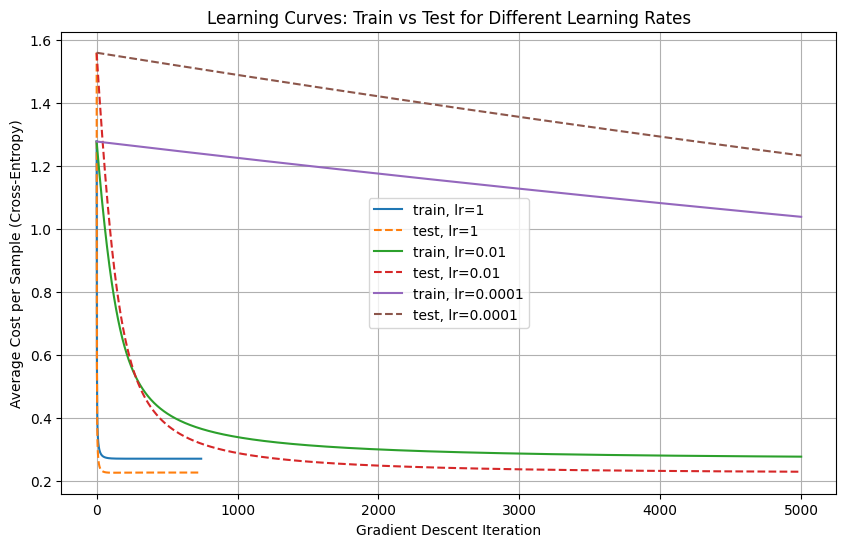

In [20]:
def run_lr(model_cls, X_train, y_train, X_test, y_test, lr, max_iter=5000, seed=0):
    np.random.seed(seed)
    model = model_cls()

    # initalize weights
    # w_init = np.random.rand(X_train.shape[1])

    model.fit(
        X_train,
        y_train,
        w_init=None,
        lr=lr,
        max_iter=max_iter,
        delta_thresh=1e-6,
        verbose=False,
    )

    train_curve = model.learning_curve(X_train, y_train)
    test_curve = model.learning_curve(X_test, y_test)
    return model, train_curve, test_curve


# learning rates to try
lrs = [10**0, 10**-2, 10**-4]

models = {}
curves = {}

for lr in lrs:
    # run logistic regresion and save model and learning curves for this learning rate
    m, tr, te = run_lr(
        Logistic_regression,
        X_train_p,
        y_train,
        X_test_p,
        y_test,
        lr=lr,
        max_iter=5000,
        seed=0,
    )
    models[lr] = m
    curves[lr] = (tr, te)

# plot 6
plt.figure(figsize=(10, 6))

for lr in lrs:
    tr, te = curves[lr]
    plt.plot(tr, label=f"train, lr={lr:g}")
    plt.plot(te, linestyle="--", label=f"test, lr={lr:g}")

plt.xlabel("Gradient Descent Iteration")
plt.ylabel("Average Cost per Sample (Cross-Entropy)")
plt.title("Learning Curves: Train vs Test for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

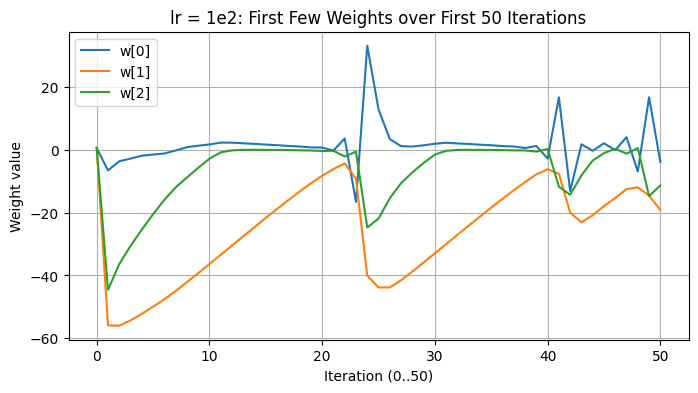

In [21]:
# big learning rate run (lr = 1e2), keep only first 50 iterations of weights
np.random.seed(0)
big_lr = 1e2

big_model = Logistic_regression()
big_model.fit(
    X_train_p,
    y_train,
    w_init=None,
    lr=big_lr,
    max_iter=50,
    delta_thresh=0,
    verbose=False,
)

W = np.array(big_model.saved_w)
dW = W[1:] - W[:-1]
step_norms = np.linalg.norm(dW, axis=1)

# plot weights
plt.figure(figsize=(8, 4))
for j in range(min(5, W.shape[1])):
    plt.plot(W[:, j], label=f"w[{j}]")
plt.xlabel("Iteration (0..50)")
plt.ylabel("Weight value")
plt.title("lr = 1e2: First Few Weights over First 50 Iterations")
plt.legend()
plt.grid(True)
plt.show()

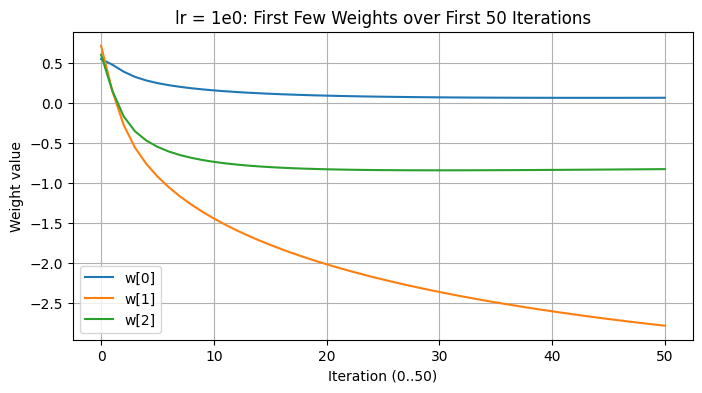

In [22]:
# smaller learning rate run (lr = 1), keep only first 50 iterations of weights
np.random.seed(0)
small_lr = 1e0

small_model = Logistic_regression()
small_model.fit(
    X_train_p,
    y_train,
    w_init=None,
    lr=small_lr,
    max_iter=50,
    delta_thresh=0,
    verbose=False,
)

W = np.array(small_model.saved_w)
dW = W[1:] - W[:-1]
step_norms = np.linalg.norm(dW, axis=1)

# plot weights
plt.figure(figsize=(8, 4))
for j in range(min(5, W.shape[1])):
    plt.plot(W[:, j], label=f"w[{j}]")
plt.xlabel("Iteration (0..50)")
plt.ylabel("Weight value")
plt.title("lr = 1e0: First Few Weights over First 50 Iterations")
plt.legend()
plt.grid(True)
plt.show()

For  $\eta = 10^{-4}$\, convergence is very slow and the cost does not decrease much within 5,000 iterations. For $\eta = 10^{-2}$, the cost decreases smoothly and pretty steady, showing stable convergence. For $ \eta = 10^{0}$, the cost drops fastest and converges quickly while remaining stable. And the very large learning rate of $10^{2}$ causes more instability because of overshooting, as the plot above shows more oscillations.

Overall, $\eta = 10^{0}$ (i.e. 1) is preferred because it converges the fastest while maintaining stability.


<div style="page-break-before: always;"></div>


### E: Evaluate your model performance through cross validation ###

#### 1.9 ####

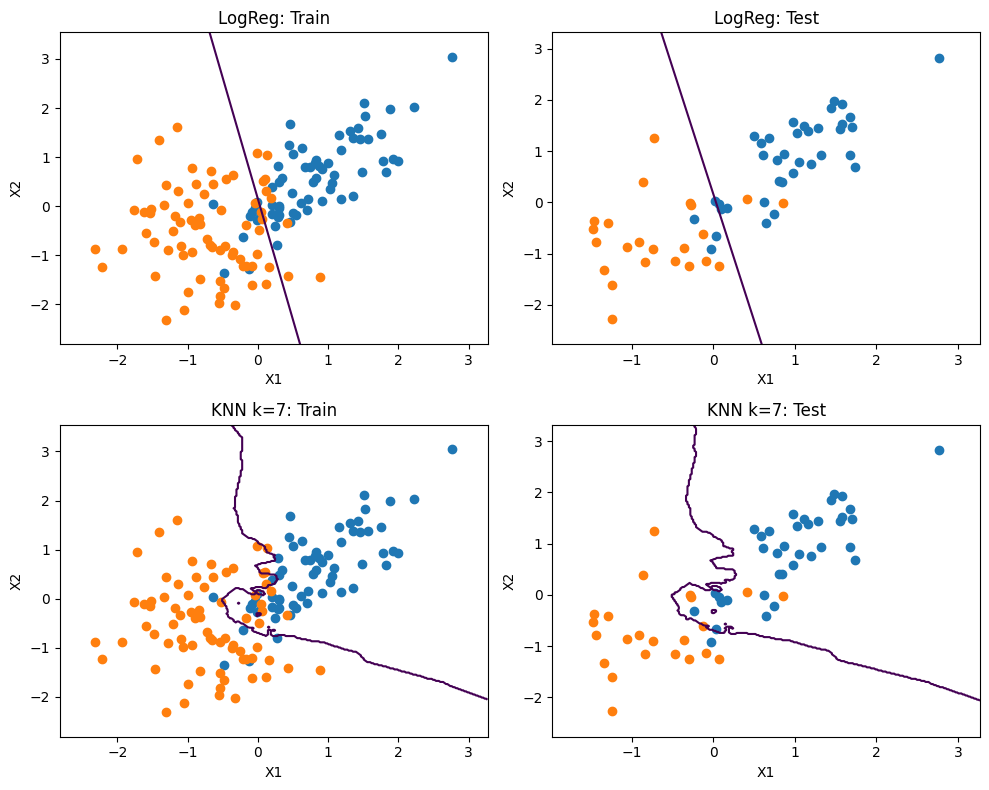

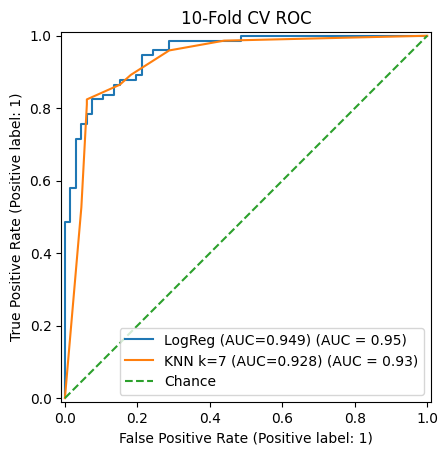

In [23]:
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import RocCurveDisplay, roc_auc_score

Xtr = np.asarray(X_train)
ytr = np.asarray(y_train).reshape(-1)
Xte = np.asarray(X_test)
yte = np.asarray(y_test).reshape(-1)

lr = 1
k = 7
tmp = Logistic_regression()

lr_model = Logistic_regression()
lr_model.fit(tmp.prepare_x(Xtr), ytr, w_init=np.random.rand(3), lr=lr)

knn_model = KNeighborsClassifier(n_neighbors=k)
knn_model.fit(Xtr, ytr)


def plot_boundary(ax, model, X, y, is_lr, title):
    # Create a grid of points to evaluate the model
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]

    if is_lr:
        Z = model.predict_proba(tmp.prepare_x(grid))
    else:
        Z = model.predict_proba(grid)[:, 1]

    Z = Z.reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[0.5])
    ax.scatter(X[y == 0, 0], X[y == 0, 1])
    ax.scatter(X[y == 1, 0], X[y == 1, 1])
    ax.set_title(title)
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")


fig, axs = plt.subplots(2, 2, figsize=(10, 8))
plot_boundary(axs[0, 0], lr_model, Xtr, ytr, True, "LogReg: Train")
plot_boundary(axs[0, 1], lr_model, Xte, yte, True, "LogReg: Test")
plot_boundary(axs[1, 0], knn_model, Xtr, ytr, False, "KNN k=7: Train")
plot_boundary(axs[1, 1], knn_model, Xte, yte, False, "KNN k=7: Test")
plt.tight_layout()
plt.show()

X = Xtr
y = ytr

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

lr_pred = np.zeros(len(y))
knn_pred = np.zeros(len(y))

for tr_idx, te_idx in kfold.split(X, y):
    # train logistic regression and knn on the training fold and save predictions on the validation fold
    X_train_cv, X_val_cv = X[tr_idx], X[te_idx]
    y_train_cv = y[tr_idx]

    m_lr = Logistic_regression()
    m_lr.fit(tmp.prepare_x(X_train_cv), y_train_cv, w_init=np.random.rand(3), lr=lr)
    lr_pred[te_idx] = m_lr.predict_proba(tmp.prepare_x(X_val_cv))

    # use KNN and save predictions on validation fold
    m_knn = KNeighborsClassifier(n_neighbors=k)
    m_knn.fit(X_train_cv, y_train_cv)
    knn_pred[te_idx] = m_knn.predict_proba(X_val_cv)[:, 1]

auc_lr = roc_auc_score(y, lr_pred)
auc_knn = roc_auc_score(y, knn_pred)

fig, ax = plt.subplots()
RocCurveDisplay.from_predictions(y, lr_pred, name=f"LogReg (AUC={auc_lr:.3f})", ax=ax)
RocCurveDisplay.from_predictions(
    y, knn_pred, name=f"KNN k=7 (AUC={auc_knn:.3f})", ax=ax
)
ax.plot([0, 1], [0, 1], "--", label="Chance")
ax.set_title("10-Fold CV ROC")
ax.legend()
plt.show()

Cross validation helps us get a more reliable estimate of how the model will perform on new, unseen data. Instead of relying on just one train/test split, it evaluates the model on many splits, which reduces the chance that our results are due to randomness in a single split.

From the ROC curves, logistic regression performs slightly better, with a higher AUC than KNN. The decision boundary for logistic regression is more clean and linear, which fits this dataset well, while KNN creates a more complex and loose boundary. I would choose logistic regression because it performs slightly better and is simpler and more stable. I’m decently confident, but having more data or testing on a completely separate validation set could increase my confidence.

<div style="page-break-before: always;"></div>


## Exercise 2 - Digits classification


In [24]:
# Load the MNIST Data
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pickle

# Set this to True to download the data for the first time and False after the first time
#   so that you just load the data locally instead
download_data = True

if download_data:
    # Load data from https://www.openml.org/d/554
    X, y = fetch_openml("mnist_784", return_X_y=True, as_frame=False)

    # Adjust the labels to be '1' if y==3, and '0' otherwise
    y[y != "3"] = 0
    y[y == "3"] = 1
    y = y.astype("int")

    # Divide the data into a training and test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=1 / 7, random_state=88
    )

    file = open("tmpdata", "wb")
    pickle.dump((X_train, X_test, y_train, y_test), file)
    file.close()
else:
    file = open("tmpdata", "rb")
    X_train, X_test, y_train, y_test = pickle.load(file)
    file.close()

### 2.1 ###

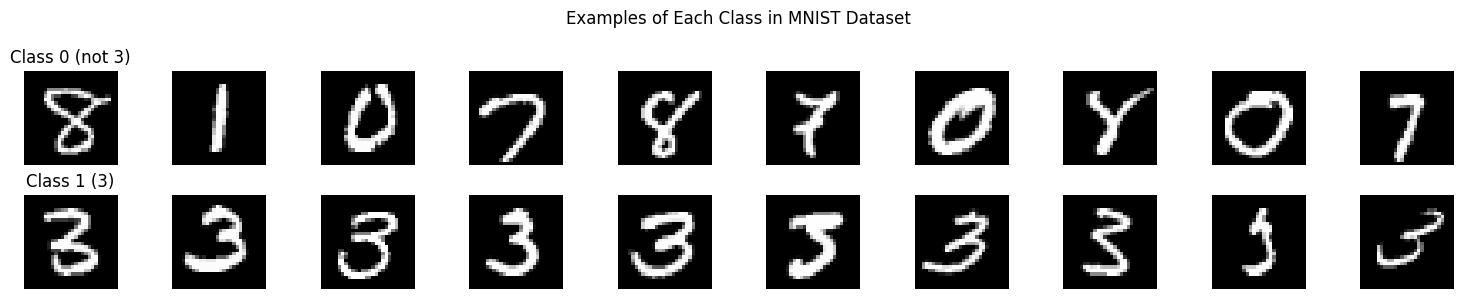

In [25]:
# plot 10 examples of each class but reshape the 784 features into 28x28 images
fig, axs = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    class_0_idx = np.where(y_train == 0)[0][i]
    class_1_idx = np.where(y_train == 1)[0][i]

    axs[0, i].imshow(X_train[class_0_idx].reshape(28, 28), cmap="gray")
    axs[0, i].axis("off")

    axs[1, i].imshow(X_train[class_1_idx].reshape(28, 28), cmap="gray")
    axs[1, i].axis("off")

# title and labels for plot
axs[0, 0].set_title("Class 0 (not 3)")
axs[1, 0].set_title("Class 1 (3)")
plt.suptitle("Examples of Each Class in MNIST Dataset")
plt.tight_layout()
plt.show()

<div style="page-break-before: always;"></div>


### 2.2 ###

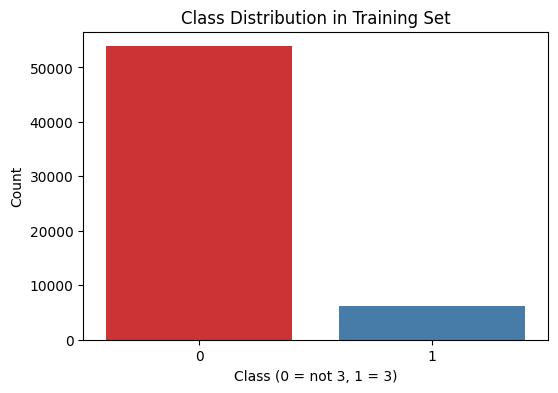

In [26]:
# plot samples by class bar plot, what fraction of samples are posiitve
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, palette="Set1")
plt.title("Class Distribution in Training Set")
plt.xlabel("Class (0 = not 3, 1 = 3)")
plt.ylabel("Count")

plt.show()

In [27]:
num_class_0 = len(np.where(y_train == 0)[0])
num_class_1 = len(np.where(y_train == 1)[0])

print("Number of class 0 (digits not 3) samples:", num_class_0)
print("Number of class 1 (digits are 3) samples:", num_class_1)
print("Fraction of positive samples: ", num_class_1 / (num_class_0 + num_class_1))

Number of class 0 (digits not 3) samples: 53871
Number of class 1 (digits are 3) samples: 6129
Fraction of positive samples:  0.10215


**Out of the samples, .10215 or about 10% are positive, i.e. digit 3. This could be problematic as there would be class imbalance since there is such a large difference in the proportion of class 0 versus class 1.**

<div style="page-break-before: always;"></div>


### 2.3 ###

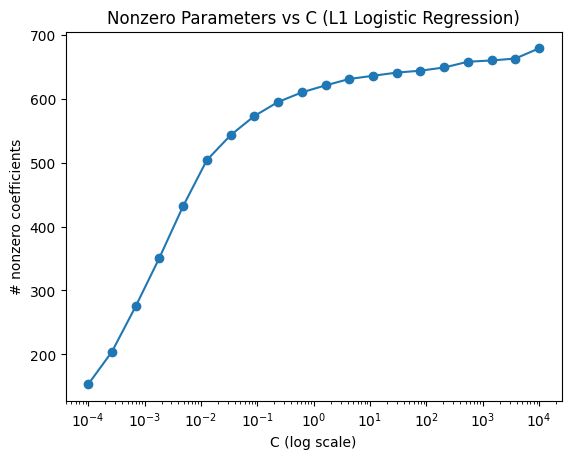

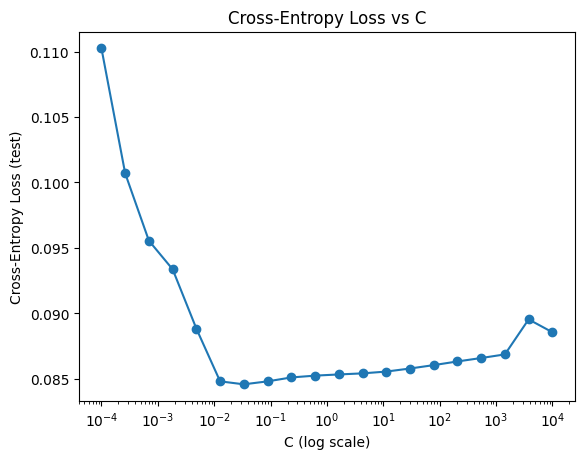

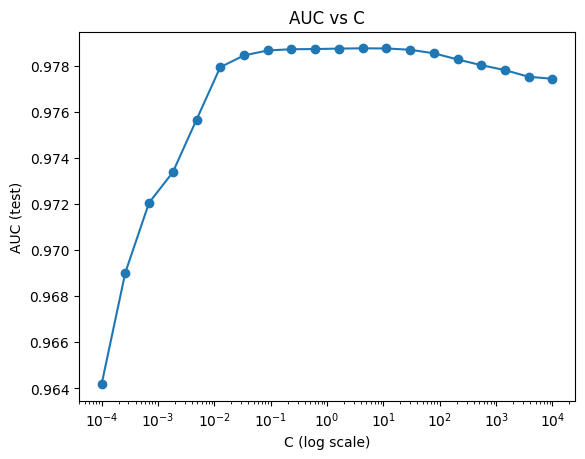

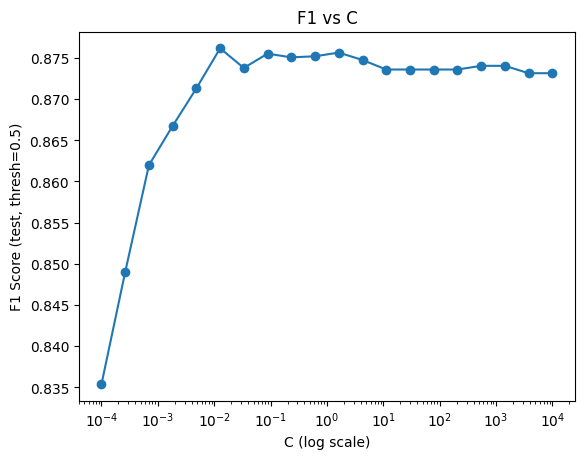

In [28]:
## working


scaler = StandardScaler()
# X_train_s = scaler.fit_transform(X_train)
# X_test_s  = scaler.transform(X_test)
X_train_s = X_train.copy()
X_test_s = X_test.copy()

c_values = np.logspace(-4, 4, 20)

nonzero = []
ce_loss = []
auc_vals = []
f1_vals = []

for C in c_values:
    # initialize logistic regression model
    model = LogisticRegression(
        penalty="l1",
        C=C,
        solver="liblinear",
        max_iter=1000,
    )

    # fit model and predict
    model.fit(X_train_s, y_train)

    probs = model.predict_proba(X_test_s)[:, 1]
    preds = model.predict(X_test_s)

    # get metrics for plots
    nonzero.append(np.count_nonzero(model.coef_))
    ce_loss.append(log_loss(y_test, probs))
    auc_vals.append(roc_auc_score(y_test, probs))
    f1_vals.append(f1_score(y_test, preds))

# plot the metrics

plt.figure()
plt.semilogx(c_values, nonzero, marker="o")
plt.xlabel("C (log scale)")
plt.ylabel("# nonzero coefficients")
plt.title("Nonzero Parameters vs C (L1 Logistic Regression)")
plt.show()

plt.figure()
plt.semilogx(c_values, ce_loss, marker="o")
plt.xlabel("C (log scale)")
plt.ylabel("Cross-Entropy Loss (test)")
plt.title("Cross-Entropy Loss vs C")
plt.show()

plt.figure()
plt.semilogx(c_values, auc_vals, marker="o")
plt.xlabel("C (log scale)")
plt.ylabel("AUC (test)")
plt.title("AUC vs C")
plt.show()

plt.figure()
plt.semilogx(c_values, f1_vals, marker="o")
plt.xlabel("C (log scale)")
plt.ylabel("F1 Score (test, thresh=0.5)")
plt.title("F1 vs C")
plt.show()

**The best value of C is 0.01. The performance (based on AUC, F1, Cross Entropy loss) improves fast as C increases from small values and plateaus around 0.01 on the plots. The larger values of C reduce sparsity but don't meaningfully improve the performance so 0.01 is the best tradeoff. The AUC and F1 plots show values are pretty much flat from a C value of 0.01 and after, with loss barely improving after that. Smaller C gives more regularization since the lambda penatly is 1/0.01--> 100 while the model is simple as it is pushing more weights to zero and sparser.**

<div style="page-break-before: always;"></div>


### 2.4 ###

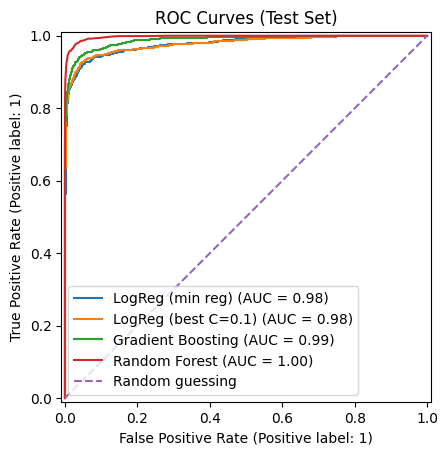

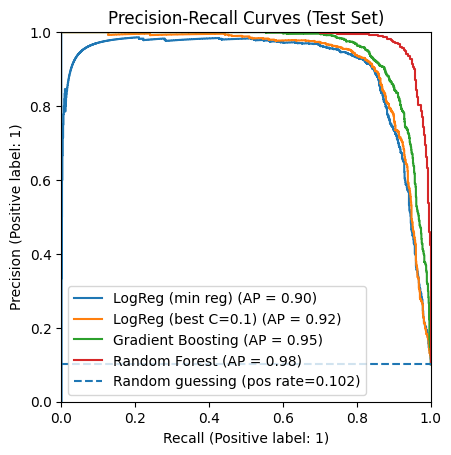

In [29]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# y_train = np.asarray(y_train).reshape(-1)
# y_test  = np.asarray(y_test).reshape(-1)

# scaler = StandardScaler()
# X_train_s = scaler.fit_transform(X_train)
# X_test_s  = scaler.transform(X_test)

C_best = 0.01
C_min_reg = 1e100

models = {
    "LogReg (min reg)": LogisticRegression(
        penalty="l1",
        C=C_min_reg,
        solver="liblinear",
        max_iter=1000,
    ),
    "LogReg (best C=0.1)": LogisticRegression(
        penalty="l1",
        C=C_best,
        solver="liblinear",
        max_iter=1000,
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(random_state=0),
}

scores = {}

for name, model in models.items():
    if "LogReg" in name:
        model.fit(X_train_s, y_train)
        scores[name] = model.predict_proba(X_test_s)[:, 1]
    else:
        model.fit(X_train, y_train)
        scores[name] = model.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots()
for name, s in scores.items():
    RocCurveDisplay.from_predictions(y_test, s, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "--", label="Random guessing")
ax.set_title("ROC Curves (Test Set)")
ax.legend()
plt.show()

fig, ax = plt.subplots()
for name, s in scores.items():
    PrecisionRecallDisplay.from_predictions(y_test, s, name=name, ax=ax)
ax.hlines(
    y_train.mean(),
    0,
    1,
    linestyles="--",
    label=f"Random guessing (pos rate={y_train.mean():.3f})",
)
ax.set_title("Precision-Recall Curves (Test Set)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
plt.show()

All of the models performed pretty well, with the two logistic regression models (minimal regularization and with C = 0.1) both getting very similar ROC curves and AUC around 0.98 and AP (avg precision) of 0.91. This shows that regularization didn't make that much of a difference but may have still helped with model sparsity and stability.

Gradient Boosting improves the performance slighlty with higher AUC (0.99) and AP (0.95) and Rankdom Forest performs best with the highest ROC and PR curves (AUC 1.0 and AP 0.98). This shows that the ensemble methods perform better than logistic regression, especially in the precision recall performance where there's a larger gap. 

For the unseen data, I would choose a Random Forest classifier for this reason since it achieves the highest overall performance across the ROC and PR curves and can capture nonlinear patterns that logistic regression can't, which allows it to better clasisfy the digit '3'.

<div style="page-break-before: always;"></div>


### 2.5 ###

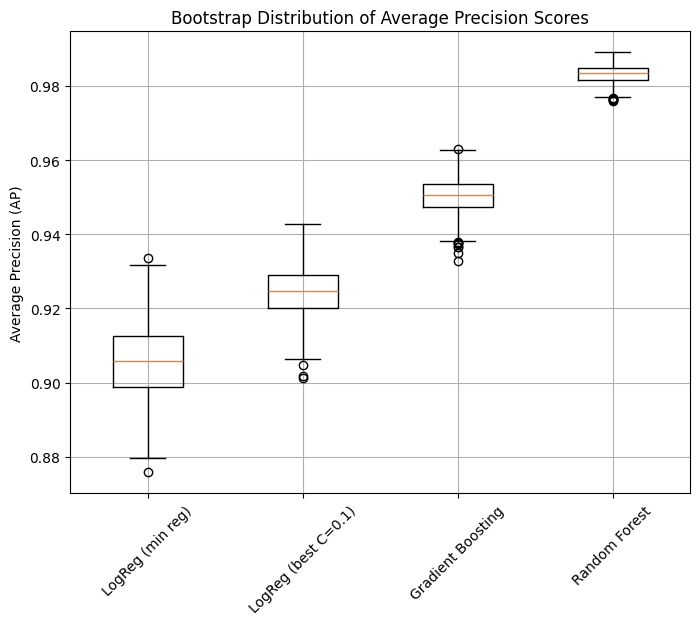

In [30]:
from sklearn.metrics import average_precision_score

# create 1000 boostrapped sample test datasets


scores = {}
bootstrapped_datasets = []
for i in range(1000):
    idx = np.random.choice(len(X_test), size=len(X_test), replace=True)
    X_test_boot = X_test[idx]
    y_test_boot = y_test[idx]
    bootstrapped_datasets.append((X_test_boot, y_test_boot))

    # for each model compute average precision (area under the precision-recall curve) on the bootstrapped dataset and save results
    for name, model in models.items():
        if "LogReg" in name:
            p = model.predict_proba(X_test_boot)[:, 1]
        else:
            p = model.predict_proba(X_test_boot)[:, 1]
        ap = average_precision_score(y_test_boot, p)
        if name not in scores:
            scores[name] = []
        scores[name].append(ap)

        # create box and whisker plot of the average precision scores for each model across the bootstrapped datasets
plt.figure(figsize=(8, 6))
plt.boxplot([scores[name] for name in models.keys()], labels=models.keys())
plt.ylabel("Average Precision (AP)")
plt.title("Bootstrap Distribution of Average Precision Scores")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**The bootstrap distribution above shows that Random Forest achieves the highest average precision as it has the highest median and smallest variability across the resamples. Gradient boosting performs slightly worse than RF, but both still outperform the logistic regression models. The two logistic regression models (with minimal regularization C =1e100  and C= 0.1) have very similar Average Precision distributions, which shows that regularization didn't significantly change the performance. This makese sense since the problem is already decently well separated so the additional regularization on MNIST mainly affects sparsity rather than the predictive performance and doesn't change the decision boundary dramatically. This shows that the ensemble methods perform better than logsitic variation, not just due to random sampling variation but over bootstrapping samples, as they are more robust for this classification task on unseen data.**

<div style="page-break-before: always;"></div>


### End Submission ###

In [35]:
!jupyter nbconvert --to html hw3.ipynb --TemplateExporter.exclude_input_prompt=True

[NbConvertApp] WARNING | Config option `exclude_output_stderr` not recognized by `HTMLExporter`.  Did you mean one of: `exclude_output, exclude_output_prompt, exclude_output_stdin`?
[NbConvertApp] Converting notebook hw3.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 15 image(s).
[NbConvertApp] Writing 1153333 bytes to hw3.html
